In [1]:
import os
import sys
import pickle
import numpy as np
import pandas as pd

# allow importing the "backbone" package when the kernel's cwd is noteonooks/
sys.path.append(os.path.abspath(".."))

import backbone.custom_metrics.AstroMLmod3 as AstroMLmod
import backbone.custom_metrics.Intrinsic_dimension as id_module
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import davies_bouldin_score

<Figure size 640x480 with 0 Axes>

# Test representations: TPCF & ID scores per epoch

In [ ]:
n_epochs = 100

tpcf_scores = []
tpcf_std_scores = []
id_scores = []
cosine_sim_scores = []
cosine_sim_std_scores = []
anisotropy_scores = []
davies_bouldin_scores = []

for epoch in range(n_epochs):
    pkl_filename = f"../Plots/Test_representations_labels{epoch}.csv"
    with open(pkl_filename, 'rb') as file:
        test_rep = pickle.load(file)

    representations = np.array(test_rep[0])
    labels = test_rep[1]
    n = representations.shape[0]

    # TPCF_score bootstraps over subsamples and returns (mean, std)
    tpcf, tpcf_std = AstroMLmod.TPCF_score(representations, epoch=epoch)
    id_ = id_module.id_score(representations)
    db_score = davies_bouldin_score(representations, labels)

    # average pairwise cosine similarity, excluding self-similarity on the diagonal
    cos_sim_matrix = cosine_similarity(representations)
    off_diag_mask = ~np.eye(n, dtype=bool)
    avg_cos_sim = cos_sim_matrix[off_diag_mask].mean()
    std_cos_sim = cos_sim_matrix[off_diag_mask].std()

    # anisotropy: fraction of variance explained by the top singular direction
    centered = representations - representations.mean(axis=0, keepdims=True)
    singular_values = np.linalg.svd(centered, compute_uv=False)
    explained_variance = (singular_values ** 2) / (n - 1)
    explained_variance_ratio = explained_variance / explained_variance.sum()
    anisotropy = explained_variance_ratio[0]

    tpcf_scores.append(tpcf)
    tpcf_std_scores.append(tpcf_std)
    id_scores.append(id_)
    cosine_sim_scores.append(avg_cos_sim)
    cosine_sim_std_scores.append(std_cos_sim)
    anisotropy_scores.append(anisotropy)
    davies_bouldin_scores.append(db_score)

    print(f"Epoch {epoch}: TPCF={tpcf:.4f}±{tpcf_std:.4f} ID={id_} CosineSim={avg_cos_sim:.4f}±{std_cos_sim:.4f} Anisotropy={anisotropy:.4f} DaviesBouldin={db_score:.4f}")


[    0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     2     0     2     0     0     2     4     0     2     2
     0     6     2    12    16    14    16    34    36    48    72    76
    78   110   174   176   210   266   342   446   546   546   698   854
   912  1106  1308  1590  1620  1920  2132  2448  2848  3234  3626  3960
  4462  4958  5420  5912  6474  6948  7600  8742  9090  9798 10670 11420
 12148 13046 13844 14648 15698 16826 18012 18352 19326 20654 21516 22382
 23138 24278 25338]
[    0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     2     2     0     0     0     0     2     4     8     6     8
    12    20    24    50    38    60    70    76   122   146   186   230
   278   334   434   578   702   744   888  1094  1220  1456  1672  1970
  2160  2594  2940  3270  3710 

In [ ]:
results = pd.DataFrame({
    "epoch": range(n_epochs),
    "tpcf_score": tpcf_scores,
    "tpcf_std": tpcf_std_scores,
    "id_mean": [i[0] for i in id_scores],
    "id_std": [i[1] for i in id_scores],
    "avg_cosine_similarity": cosine_sim_scores,
    "cosine_similarity_std": cosine_sim_std_scores,
    "anisotropy": anisotropy_scores,
    "davies_bouldin": davies_bouldin_scores,
})

# keep pickle format for compatibility with existing plotting notebooks
with open("Test_TPCF_score.csv", "wb") as file:
    pickle.dump(tpcf_scores, file)

with open("Test_id_score.csv", "wb") as file:
    pickle.dump(id_scores, file)

results.to_csv("Test_TPCF_id_scores.csv", index=False)
results


,epoch,tpcf_score,id_mean,id_std,avg_cosine_similarity,anisotropy,davies_bouldin
0,0,131091.016697,53.384136,1.033585,0.195290,0.968971,12.242701
1,1,129626.753666,6.583923,0.239878,0.813158,0.993488,3.340510
2,2,87297.291772,5.460909,0.196058,0.773033,0.193982,2.108989
3,3,102635.884736,5.005268,0.102866,0.764261,0.204972,1.955844
4,4,88937.147218,4.864514,0.114644,0.754089,0.197458,1.474272
...,...,...,...,...,...,...,...
95,95,103072.266918,4.328184,0.128421,0.584419,0.190735,1.420186
96,96,99486.942675,4.592262,0.124002,0.593365,0.191867,1.574932
97,97,97868.828734,4.263826,0.113400,0.585264,0.190268,1.334020
98,98,97268.633886,4.171560,0.067502,0.573901,0.197656,1.370631


findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found.
findfont: Font family 'normal' not

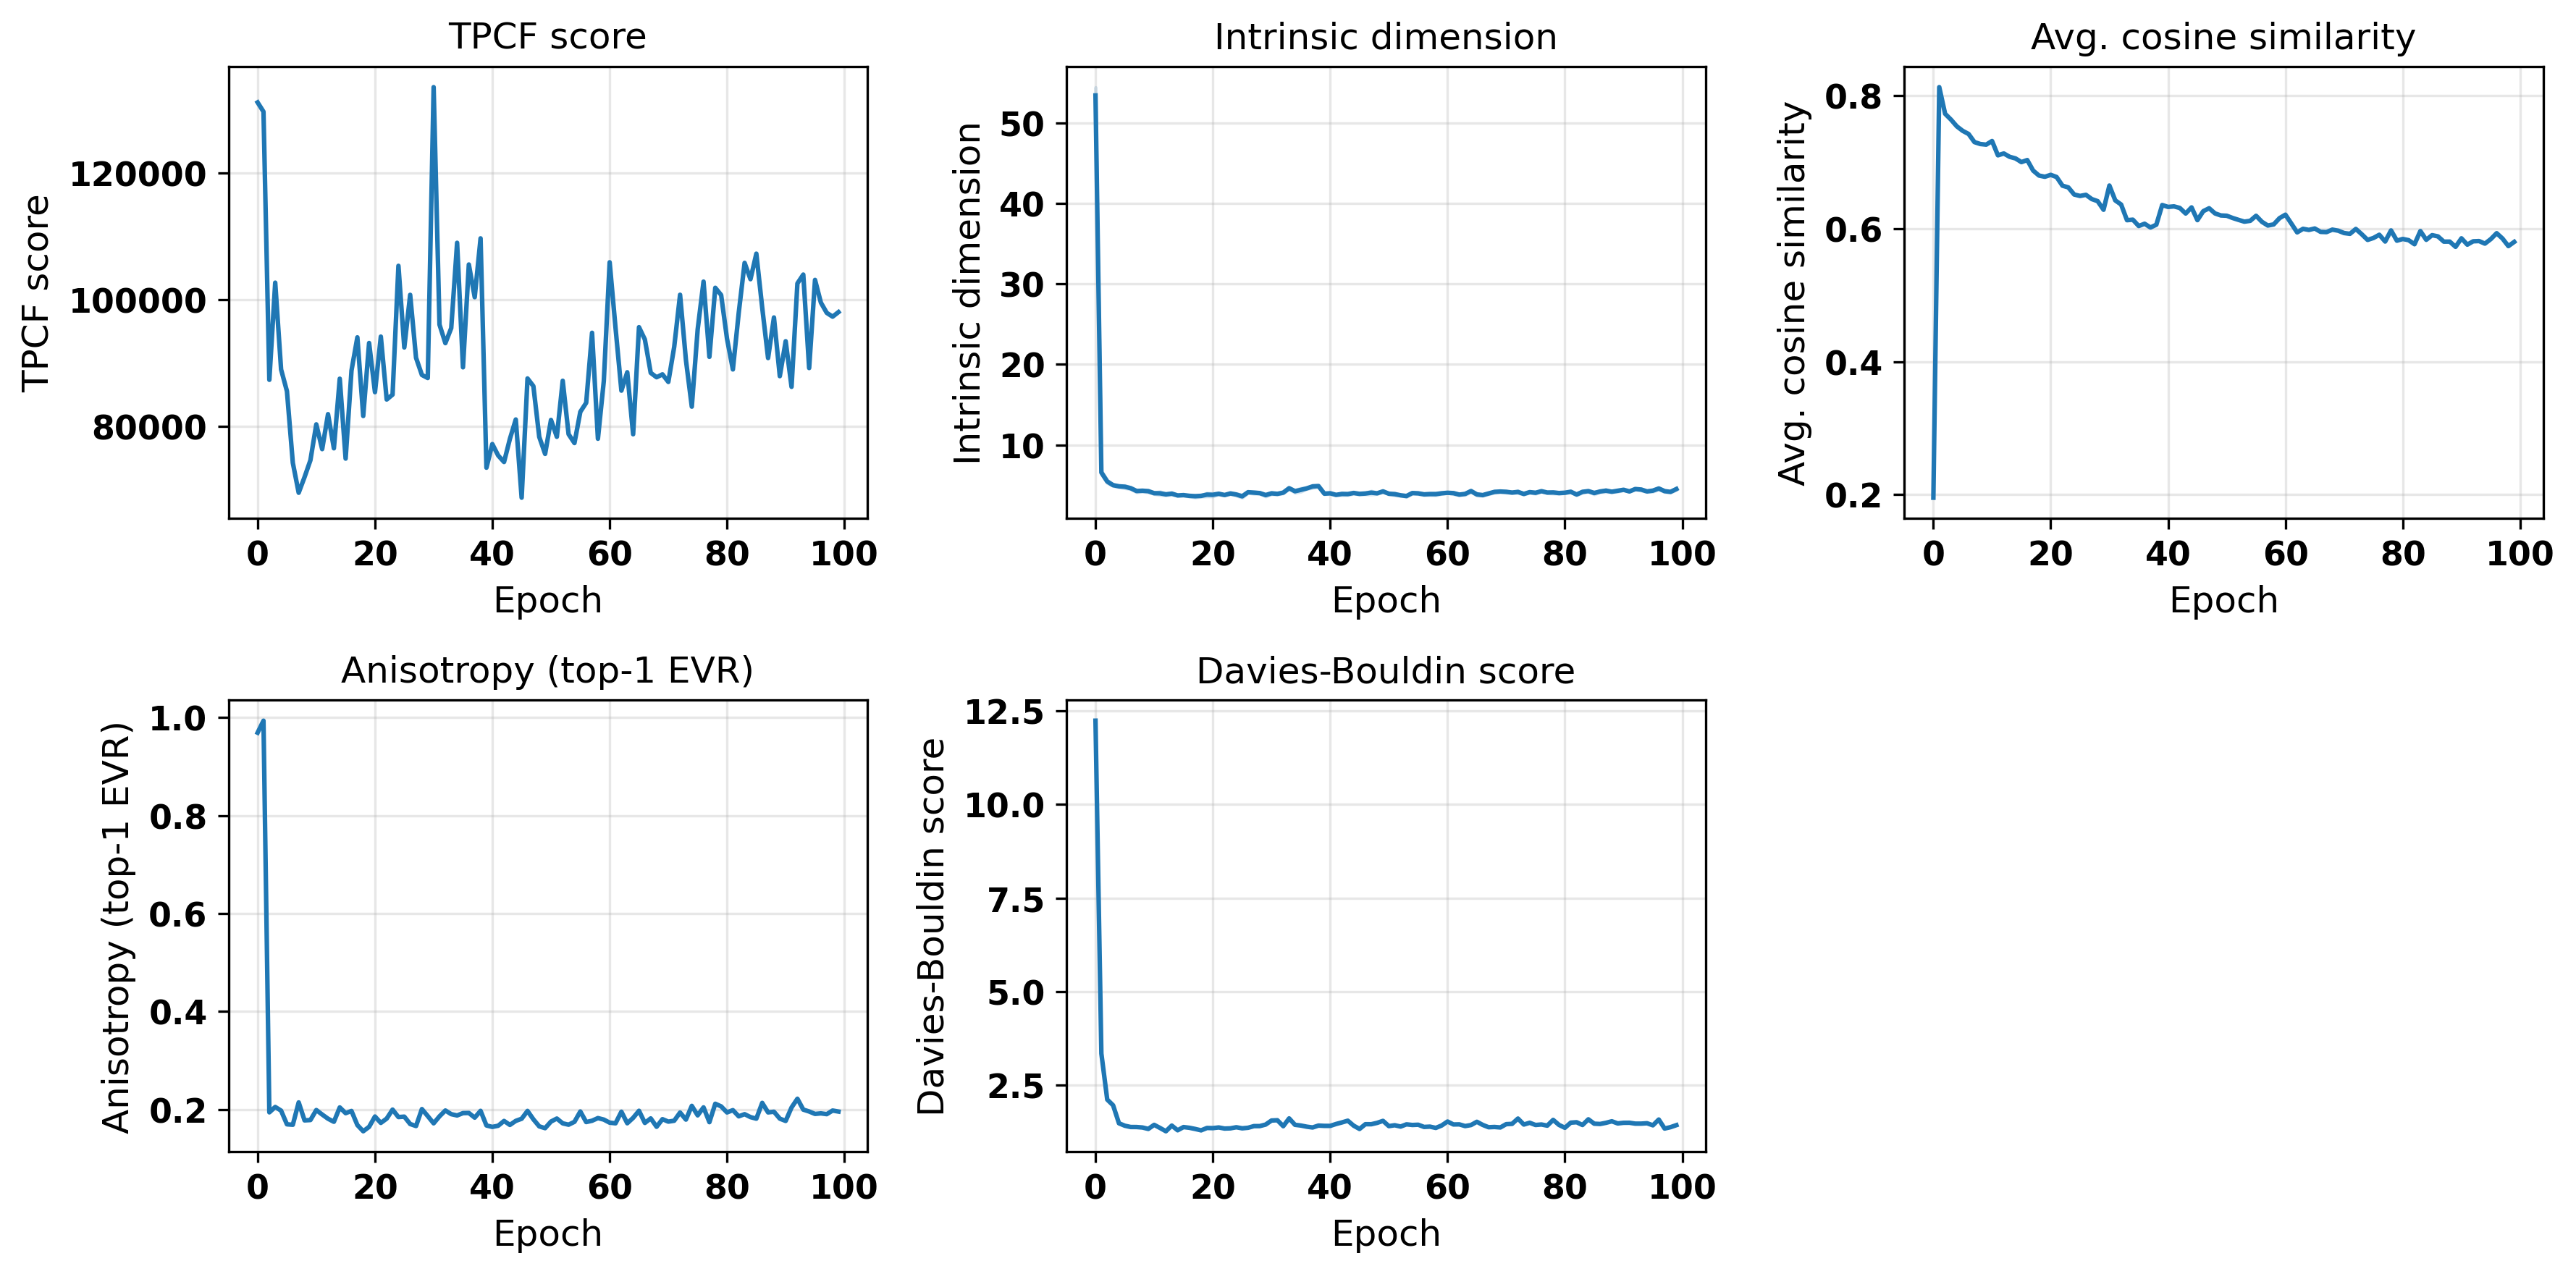

In [ ]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.dpi": 300,
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "lines.linewidth": 1.5,
})

metrics = [
    ("tpcf_score", "TPCF score", "tpcf_std"),
    ("id_mean", "Intrinsic dimension", "id_std"),
    ("avg_cosine_similarity", "Avg. cosine similarity", "cosine_similarity_std"),
    ("cosine_similarity_std", "Cosine similarity std", None),
    ("anisotropy", "Anisotropy (top-1 EVR)", None),
    ("davies_bouldin", "Davies-Bouldin score", None),
]


def plot_gradient_band(ax, x, y, y_err, color="C0", n_layers=40, max_sigma=3.0):
    """Shade the uncertainty band with an alpha gradient that fades away from the mean."""
    x = np.asarray(x)
    y = np.asarray(y)
    y_err = np.asarray(y_err)
    sigmas = np.linspace(max_sigma / n_layers, max_sigma, n_layers)
    for sigma in sigmas[::-1]:
        alpha = 0.35 * np.exp(-0.5 * sigma ** 2)
        ax.fill_between(x, y - sigma * y_err, y + sigma * y_err, color=color, alpha=alpha, linewidth=0)


n_cols = 3
n_rows = -(-len(metrics) // n_cols)  # ceil division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows), squeeze=False)
axes = axes.flatten()

for ax, (col, title, err_col) in zip(axes, metrics):
    ax.plot(results["epoch"], results[col], color="C0")
    if col == "tpcf_score":
        plot_gradient_band(ax, results["epoch"], results[col], results[err_col])
    elif err_col is not None:
        ax.fill_between(
            results["epoch"],
            results[col] - results[err_col],
            results[col] + results[err_col],
            color="C0",
            alpha=0.2,
        )
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.set_ylabel(title)

# hide any unused axes in the grid
for ax in axes[len(metrics):]:
    ax.axis("off")

fig.tight_layout()
fig.savefig("Test_metrics_grid.pdf", bbox_inches="tight")
plt.show()
